# Discovering conservative patterns in the results of probing RNA-protein binding sites

 - Mateusz Tabaszewski 151945
 - Bartłomiej Pukacki 151942
 - Adam Mielniczuk 151928
 - Krzysztof Weber 151934

## TODO:
 - Double check because I have no idea if its correct
 - Expand/Fix clustering, right now it sucks
 - Add short descriptions/conculsions to each section

## Imports

In [1]:
from pathlib import Path
from typing import Union
import glob
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import itertools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import stumpy
from tqdm import tqdm

## Functions

### Preprocessing

In [2]:
def transform_to_dataframes(promising_binding_sites):
    result_dfs = {}
    
    for length, motifs in promising_binding_sites.items():
        rows = []
        for motif in motifs:
            row = {}
            sequence = ""
            for i, (val, char) in enumerate(motif):
                row[f'val{i+1}'] = val
                sequence += str(char)
            row['str_representation'] = sequence
            rows.append(row)
        df = pd.DataFrame(rows)
        result_dfs[length] = df
    return result_dfs

def read_protein_pattern(note_path: Path):
    parsed_file = []
    with open(note_path, "r") as note_file:
        data = note_file.read().strip().split("\n")
        for example in data:
            try:
                value = float(example.split("\t")[0])
            except Exception:
                value = None
            character = example.split("\t")[1]
            parsed_file.append((value, character))
    return parsed_file

def extract_motiff_length(motiff_representation: Union[list, tuple], expand: int=2):
    acceptable_lengths = []
    for i in range(expand+1):
        acceptable_lengths.append(len(motiff_representation)+i)
    return acceptable_lengths

def find_all_txts(dir: Path):
    txts = glob.glob("*.txt", root_dir=dir)
    return txts

def sliding_window_reactivity(protein_pattern: list, window_size: int, min_reactivity: float=1.0):
    results = []
    if window_size > len(protein_pattern):
        return results
    for i in range(len(protein_pattern) - window_size + 1):
        protein_slice = protein_pattern[i: i+window_size]
        for val in protein_slice:
            if val[0] is not None and val[0]>= min_reactivity:
                results.append(protein_slice)
                break
    return results

### Clustering

In [3]:
def get_scaled_features(df, val_cols):
    scaler = StandardScaler()
    return scaler.fit_transform(df[val_cols].values)

def optimize_kmeans(data, max_k):
    results = []
    
    for k in range(3, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        
        results.append({"k": k, "score": score, "model": kmeans, "labels": labels})
        print(f"Clusters: {k} | Silhouette Score: {score:.4f}")

    best_run = max(results, key=lambda x: x['score'])
    return best_run


def optimize_agglomerative(data, k_range=None, linkages=None, metrics=None):
    results = []
    for linkage, k in itertools.product(linkages, k_range):
        current_metrics = ['euclidean'] if linkage == 'ward' else metrics
        
        for metric in current_metrics:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric=metric)
                labels = model.fit_predict(data)
                
                score = silhouette_score(data, labels)
                
                results.append({
                    'linkage': linkage,
                    'k': k,
                    'metric': metric,
                    'silhouette_score': score,
                    'labels': labels,
                })
            except Exception as e:
                continue

    results_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
    best_config = results_df.iloc[0].to_dict()
    return best_config, results_df

def optimize_dbscan(data, eps_range, min_samples_range, max_noise_ratio=0.5):
    results = []

    for eps, min_samples in itertools.product(eps_range, min_samples_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(data)
        
        noise_ratio = np.sum(labels == -1) / len(labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1 and noise_ratio <= max_noise_ratio:
            
            core_samples_mask = labels != -1
            
            score = silhouette_score(
                data[core_samples_mask], 
                labels[core_samples_mask]
            )
            
            results.append({
                'eps': round(eps, 2),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'noise_ratio': round(noise_ratio, 3),
                'silhouette_score': score,
                'labels': labels,
            })

    if not results:
        print("No configurations met the criteria (try expanding eps_range or increasing max_noise_ratio).")
        return None, pd.DataFrame()

    results_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
    best_config = results_df.iloc[0].to_dict()
    
    return best_config, results_df

def optimize_gmm(data, n_components_range, covariance_types=['full', 'tied', 'diag', 'spherical']):
    results = []

    for n_components in n_components_range:
        for cov_type in covariance_types:
            
            gmm = GaussianMixture(
                n_components=n_components, 
                covariance_type=cov_type, 
                random_state=42
            )
            gmm.fit(data)
            
            labels = gmm.predict(data)
            
            score = None
            if n_components > 1:
                score = silhouette_score(data, labels)
                
            results.append({
                'n_components': n_components,
                'covariance_type': cov_type,
                'bic': round(gmm.bic(data), 2),
                'aic': round(gmm.aic(data), 2),
                'silhouette_score': score if score is None else round(score, 4),
                'labels': labels,
            })

    if not results:
        return None, pd.DataFrame()

    # Sort by BIC ascending (lower is better)
    results_df = pd.DataFrame(results).sort_values(by='bic', ascending=True)
    best_config = results_df.iloc[0].to_dict()
    
    return best_config, results_df

def plot_cluster_grid(df, feature_cols, method_map, n_cols=3, overall_title="Clustering Comparison"):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[feature_cols])
    
    pca = PCA(n_components=2)
    components = pca.fit_transform(scaled_data)
    
    df_plot = df.copy()
    df_plot['PC1'] = components[:, 0]
    df_plot['PC2'] = components[:, 1]
    
    methods = list(method_map.keys())
    n_rows = (len(methods) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(methods):
        sns.scatterplot(
            data=df_plot, x='PC1', y='PC2', 
            hue=col, palette='tab10', ax=axes[i], legend='brief'
        )
        axes[i].set_title(method_map.get(col, col), fontweight='bold')
        axes[i].set_xlabel("Principal Component 1")
        axes[i].set_ylabel("Principal Component 2")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(overall_title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def get_top_3_clusters(df, label_col='label', ignore_negative=True, min_size=3):
    temp_df = df.copy()
    if ignore_negative:
        temp_df = temp_df[temp_df[label_col] >= 0]

    counts = temp_df[label_col].value_counts()
    valid_labels = counts[counts >= min_size].nlargest(3).index.tolist()
    
    results = [temp_df[temp_df[label_col] == label] for label in valid_labels]
    
    while len(results) < 3:
        results.append(None)

    return results[0], results[1], results[2]


### Consensus and Results

Implements the core logic for evaluating the clusters. It uses stumpy.ostinato to find the consensus sequence among the top clusters. It also contains functions to calculate the sequence similarity factor (ssf), compute the z-normalized Euclidean distance (znEd), and calculate the final scoring metric aS=10∗znEd−ssf to rank the discovered motifs

In [4]:
def get_cluster_consensus(cluster_df, val_cols):
    if cluster_df is None or cluster_df.empty or len(cluster_df) < 2:
        return None
    
    data = cluster_df[val_cols].values.astype(np.float64)
    m = data.shape[1]  # motif length
    Ts = [row for row in data]  # list of 1-D arrays
    
    try:
        radius, Ts_idx, subseq_idx = stumpy.ostinato(Ts, m=m)
        consensus = Ts[Ts_idx][subseq_idx : subseq_idx + m]
    except Exception:
        dist_matrix = cdist(data, data, metric='euclidean')
        medoid_idx = np.argmin(dist_matrix.sum(axis=1))
        consensus = data[medoid_idx]
    
    return consensus

def calculate_ssf(seq1, seq2):
    score = 0
    purines = {'A', 'G'}
    pyrimidines = {'C', 'T', 'U'}
    
    for c1, c2 in zip(seq1, seq2):
        if c1 == c2:
            score += 2
        elif (c1 in purines and c2 in purines) or (c1 in pyrimidines and c2 in pyrimidines):
            score += 1
    return score

def build_expected_seq(base_seq, target_len):
    base_len = len(base_seq)
    diff = target_len - base_len
    if diff == 0:
        return base_seq
    elif diff == 1:
        return "N" + base_seq
    elif diff == 2:
        return "N" + base_seq + "N"
    else:
        # General fallback: pad evenly
        return ("N" * (diff // 2)) + base_seq + ("N" * (diff - diff // 2))

def search_transcript_for_consensus(consensus_profile, transcript_path, original_expected_seq):
    data = pd.read_csv(transcript_path, sep='\s+', names=['fshape', 'nuc', 'extra'], header=None)
    fshape_signal = pd.to_numeric(data['fshape'], errors='coerce').fillna(0.0).values.astype(np.float64)
    nucleotides = data['nuc'].tolist()
    distance_profile = stumpy.mass(consensus_profile, fshape_signal)
    threshold = 2.5
    match_indices = np.where(distance_profile <= threshold)[0]
    
    results = []
    m = len(consensus_profile)
    
    for idx in match_indices:
        znEd = distance_profile[idx]
        match_seq = "".join(nucleotides[idx : idx + m])
        ssf = calculate_ssf(match_seq, original_expected_seq[:m])
        aS = (10 * znEd) - ssf
        
        results.append({
            'motif_sequence': match_seq,
            'position_range': f"{idx}-{idx + m}",
            'source_file': transcript_path.name,
            'znEd': round(znEd, 4),
            'ssf': ssf,
            'aS': round(aS, 4),
            'consensus_used': list(np.round(consensus_profile, 3)),
            'consensus_len': m
        })
        
    return pd.DataFrame(results)

## HNRNPA2B1

### Data Loading

Reads the experimentally expected binding pattern for HNRNPA2B1 to determine its base length (len=11)

In [5]:
protein_path_1 = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPA2B1/hnrnpa2b1_expected_pattern.txt")
motiff_1 = read_protein_pattern(protein_path_1)
motiff_1_lengths = extract_motiff_length(motiff_1)
motiff_1_lengths

[11, 12, 13]

In [6]:
motiff_1

[(0.0, 'N'),
 (1.0, 'N'),
 (2.0, 'A'),
 (3.0, 'G'),
 (2.0, 'G'),
 (0.0, 'N'),
 (0.0, 'N'),
 (1.0, 'T'),
 (0.5, 'A'),
 (0.5, 'G'),
 (0.0, 'N')]

### Extracting Promising Motiffs

Extract all continuous reactive motifs of lengths 11, 12, and 13

In [7]:
binging_sites_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPA2B1/hnrnpa2b1_binding_sites_fshape")
binding_sites_txts = find_all_txts(binging_sites_dir)
binding_sites_1 = []

for site in binding_sites_txts:
    full_path = Path(binging_sites_dir, site)
    out = read_protein_pattern(full_path)
    binding_sites_1.append(out)


promising_binding_sites_1 = {}
for window_size in motiff_1_lengths:
    promising_binding_sites_1[window_size] = []
    for binding_site in binding_sites_1:
        outs = sliding_window_reactivity(binding_site, window_size=window_size)
        if len(outs) == 0:
            continue
        for out in outs:
            promising_binding_sites_1[window_size].append(out)

In [8]:
binding_sites_df_1= transform_to_dataframes(promising_binding_sites_1)

for key in binding_sites_df_1:
    binding_sites_df_1[key] = binding_sites_df_1[key].dropna()

In [9]:
binding_sites_df_1[11].head(5)

,val1,val2,val3,val4,val5,val6,val7,val8,val9,val10,val11,str_representation
0,4.222436,2.337724,4.173553,4.839571,4.003999,1.513893,0.518080,-10.568965,-7.172759,-11.530658,-3.007048,TTGAATTGATA
1,2.337724,4.173553,4.839571,4.003999,1.513893,0.518080,-10.568965,-7.172759,-11.530658,-3.007048,0.176999,TGAATTGATAA
2,4.173553,4.839571,4.003999,1.513893,0.518080,-10.568965,-7.172759,-11.530658,-3.007048,0.176999,-1.687907,GAATTGATAAG
3,4.839571,4.003999,1.513893,0.518080,-10.568965,-7.172759,-11.530658,-3.007048,0.176999,-1.687907,-0.189982,AATTGATAAGC
4,4.003999,1.513893,0.518080,-10.568965,-7.172759,-11.530658,-3.007048,0.176999,-1.687907,-0.189982,-0.167563,ATTGATAAGCT


## Clustering

Independently applies the K-Means, Agglomerative, DBSCAN, and GMM algorithms to the extracted motifs for each specific window length

In [10]:
val_cols_11 = [f"val{i}" for i in range(1, 12)]
X_11 = get_scaled_features(binding_sites_df_1[11], val_cols_11)

val_cols_12 = [f"val{i}" for i in range(1, 13)]
X_12 = get_scaled_features(binding_sites_df_1[12], val_cols_12)

val_cols_13 = [f"val{i}" for i in range(1, 14)]
X_13 = get_scaled_features(binding_sites_df_1[13], val_cols_13)

#### Length 11

In [11]:
best_run_11 = optimize_kmeans(X_11, max_k=20)
binding_sites_df_1[11]["k_means_labels"] = best_run_11["labels"]

Clusters: 3 | Silhouette Score: 0.1065
Clusters: 4 | Silhouette Score: 0.1150
Clusters: 5 | Silhouette Score: 0.0913
Clusters: 6 | Silhouette Score: 0.0882
Clusters: 7 | Silhouette Score: 0.0938
Clusters: 8 | Silhouette Score: 0.0796
Clusters: 9 | Silhouette Score: 0.0899
Clusters: 10 | Silhouette Score: 0.0959
Clusters: 11 | Silhouette Score: 0.0858
Clusters: 12 | Silhouette Score: 0.0861
Clusters: 13 | Silhouette Score: 0.0815
Clusters: 14 | Silhouette Score: 0.0901
Clusters: 15 | Silhouette Score: 0.0812
Clusters: 16 | Silhouette Score: 0.0806
Clusters: 17 | Silhouette Score: 0.0838
Clusters: 18 | Silhouette Score: 0.0780
Clusters: 19 | Silhouette Score: 0.0766
Clusters: 20 | Silhouette Score: 0.0763


In [12]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_11, best_run_11_df = optimize_agglomerative(X_11, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_1[11]["agglomerative_labels"] = best_run_11["labels"]
best_run_11_df.head(5)

,linkage,k,metric,silhouette_score,labels
24,average,3,euclidean,0.782299,"[2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.778215,"[1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.773920,"[1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
45,single,4,euclidean,0.773723,"[3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
46,single,4,manhattan,0.773723,"[3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [13]:
# Expanded eps search space to match the PCA scale
new_eps_range = np.arange(1.0, 3.0, 0.1)
new_min_samples_range = range(5, 15)

best_run_11, best_run_11_df = optimize_dbscan(
    X_11, 
    eps_range=new_eps_range, 
    min_samples_range=new_min_samples_range,
    max_noise_ratio=0.7
)
binding_sites_df_1[11]["dbscan_labels"] = best_run_11["labels"]
best_run_11_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
4,1.1,13,2,0.628,0.187341,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, -1..."
2,1.1,11,2,0.603,0.176656,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, -1..."
3,1.1,12,3,0.617,0.124792,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, -1..."
0,1.0,6,3,0.684,0.122300,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
1,1.0,7,3,0.699,0.008843,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."


In [14]:
best_run_11, best_run_11_df = optimize_gmm(
    X_11, 
    n_components_range=range(2, 11)
)

binding_sites_df_1[11]["gmm_labels"] = best_run_11["labels"]
best_run_11_df.head(5)

,n_components,covariance_type,bic,aic,silhouette_score,labels
26,8,diag,36757.37,35775.08,-0.0400,"[3, 3, 3, 0, 0, 0, 1, 1, 4, 2, 1, 1, 1, 5, 5, ..."
30,9,diag,36818.51,35712.76,-0.0456,"[3, 3, 3, 8, 8, 8, 1, 1, 0, 2, 1, 1, 1, 5, 5, ..."
34,10,diag,36901.77,35672.57,-0.0435,"[3, 3, 3, 8, 8, 8, 1, 1, 0, 2, 1, 1, 1, 5, 5, ..."
22,7,diag,37193.23,36334.39,-0.0326,"[4, 4, 4, 0, 0, 0, 2, 3, 1, 2, 2, 1, 3, 3, 3, ..."
14,5,diag,37698.02,37086.10,-0.0106,"[4, 4, 4, 4, 4, 4, 2, 0, 1, 2, 2, 0, 0, 0, 0, ..."


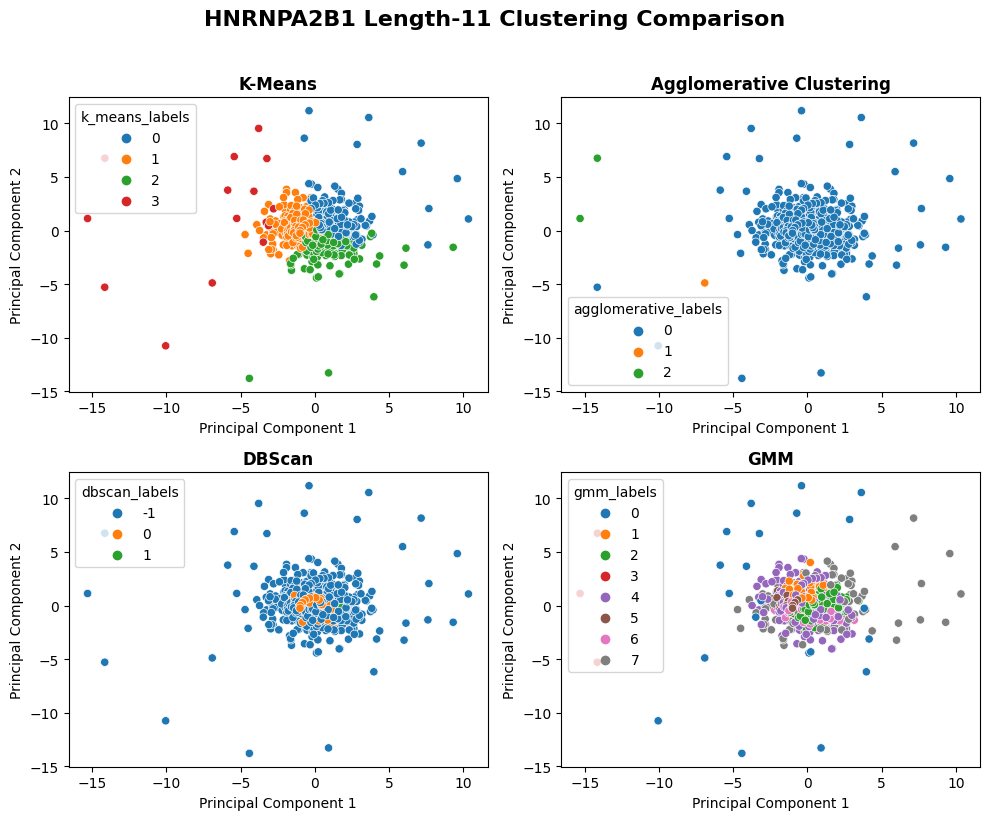

In [15]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan",
    "gmm_labels": "GMM"
}
feature_cols=[f"val{i}" for i in range(1, 12)]

plot_cluster_grid(binding_sites_df_1[11].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPA2B1 Length-11 Clustering Comparison")

#### Length 12

In [16]:
best_run_12 = optimize_kmeans(X_12, max_k=20)
binding_sites_df_1[12]["k_means_labels"] = best_run_12["labels"]

Clusters: 3 | Silhouette Score: 0.1032
Clusters: 4 | Silhouette Score: 0.0881
Clusters: 5 | Silhouette Score: 0.0876
Clusters: 6 | Silhouette Score: 0.0936
Clusters: 7 | Silhouette Score: 0.0872
Clusters: 8 | Silhouette Score: 0.0755
Clusters: 9 | Silhouette Score: 0.0856
Clusters: 10 | Silhouette Score: 0.0884
Clusters: 11 | Silhouette Score: 0.0684
Clusters: 12 | Silhouette Score: 0.0823
Clusters: 13 | Silhouette Score: 0.0841
Clusters: 14 | Silhouette Score: 0.0709
Clusters: 15 | Silhouette Score: 0.0823
Clusters: 16 | Silhouette Score: 0.0803
Clusters: 17 | Silhouette Score: 0.0797
Clusters: 18 | Silhouette Score: 0.0651
Clusters: 19 | Silhouette Score: 0.0744
Clusters: 20 | Silhouette Score: 0.0775


In [17]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_12, best_run_12_df = optimize_agglomerative(X_12, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_1[12]["agglomerative_labels"] = best_run_12["labels"]
best_run_12_df.head(5)

,linkage,k,metric,silhouette_score,labels
24,average,3,euclidean,0.774396,"[2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.770719,"[1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
45,single,4,euclidean,0.764970,"[3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
46,single,4,manhattan,0.764970,"[3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.764906,"[1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [18]:
best_run_12, best_run_12_df = optimize_dbscan(
    X_12, 
    eps_range=new_eps_range, 
    min_samples_range=new_min_samples_range,
    max_noise_ratio=0.8
)

binding_sites_df_1[12]["dbscan_labels"] = best_run_12["labels"]
best_run_12_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
6,1.1,10,2,0.734,0.226308,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
8,1.1,12,2,0.753,0.202255,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
7,1.1,11,3,0.745,0.148640,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
3,1.1,7,2,0.695,0.128911,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
1,1.0,6,2,0.791,0.040189,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."


In [19]:
best_run_12, best_run_12_df = optimize_gmm(
    X_12, 
    n_components_range=range(2, 11)
)

binding_sites_df_1[12]["gmm_labels"] = best_run_12["labels"]
best_run_12_df.head(5)

,n_components,covariance_type,bic,aic,silhouette_score,labels
26,8,diag,41311.85,40237.49,-0.0647,"[3, 3, 3, 3, 3, 3, 1, 0, 1, 1, 1, 2, 2, 2, 7, ..."
30,9,diag,41416.46,40207.14,-0.0670,"[3, 3, 3, 8, 8, 8, 1, 0, 1, 1, 1, 2, 2, 2, 7, ..."
22,7,diag,41561.64,40622.25,-0.0487,"[4, 4, 4, 4, 4, 4, 1, 0, 1, 1, 1, 2, 2, 2, 3, ..."
34,10,diag,41576.78,40232.48,-0.0540,"[3, 3, 3, 8, 8, 8, 2, 1, 6, 6, 2, 2, 2, 0, 0, ..."
18,6,diag,42145.77,41341.35,-0.0268,"[4, 4, 4, 4, 4, 4, 1, 0, 1, 1, 2, 2, 2, 2, 3, ..."


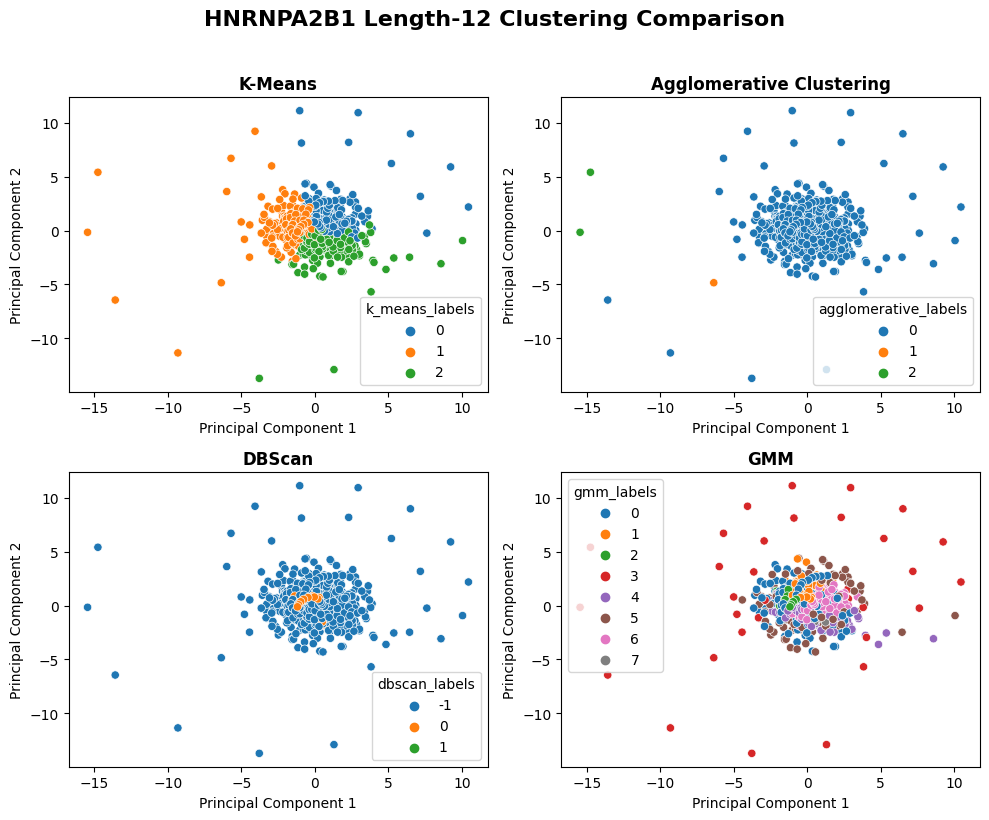

In [20]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan",
    "gmm_labels": "GMM"
}
feature_cols=[f"val{i}" for i in range(1, 13)]

plot_cluster_grid(binding_sites_df_1[12].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPA2B1 Length-12 Clustering Comparison")

#### Length 13

In [21]:
best_run_13 = optimize_kmeans(X_13, max_k=20)
binding_sites_df_1[13]["k_means_labels"] = best_run_13["labels"]

Clusters: 3 | Silhouette Score: 0.0951
Clusters: 4 | Silhouette Score: 0.0815
Clusters: 5 | Silhouette Score: 0.0790
Clusters: 6 | Silhouette Score: 0.0721
Clusters: 7 | Silhouette Score: 0.0784
Clusters: 8 | Silhouette Score: 0.0802
Clusters: 9 | Silhouette Score: 0.0757
Clusters: 10 | Silhouette Score: 0.0730
Clusters: 11 | Silhouette Score: 0.0704
Clusters: 12 | Silhouette Score: 0.0782
Clusters: 13 | Silhouette Score: 0.0800
Clusters: 14 | Silhouette Score: 0.0582
Clusters: 15 | Silhouette Score: 0.0794
Clusters: 16 | Silhouette Score: 0.0769
Clusters: 17 | Silhouette Score: 0.0776
Clusters: 18 | Silhouette Score: 0.0782
Clusters: 19 | Silhouette Score: 0.0773
Clusters: 20 | Silhouette Score: 0.0762


In [22]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_13, best_run_13_df = optimize_agglomerative(X_13, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_1[13]["agglomerative_labels"] = best_run_13["labels"]
best_run_13_df.head(5)

,linkage,k,metric,silhouette_score,labels
24,average,3,euclidean,0.766648,"[2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.762494,"[1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.756826,"[1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
45,single,4,euclidean,0.756705,"[3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
46,single,4,manhattan,0.756705,"[3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [23]:
best_run_13, best_run_13_df = optimize_dbscan(
    X_13, 
    eps_range=new_eps_range, 
    min_samples_range=new_min_samples_range,
    max_noise_ratio=0.8
)
binding_sites_df_1[13]["dbscan_labels"] = best_run_13["labels"]
best_run_13_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
4,1.2,11,2,0.741,0.215887,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, -1,..."
3,1.2,10,2,0.725,0.199722,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, -1,..."
1,1.1,6,3,0.785,0.056139,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
0,1.1,5,6,0.764,-0.003814,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
2,1.2,7,2,0.686,-0.005095,"[-1, -1, -1, -1, -1, -1, -1, 0, -1, 0, 0, -1, ..."


In [24]:
best_run_13, best_run_13_df = optimize_gmm(
    X_13, 
    n_components_range=range(2, 11)
)

binding_sites_df_1[13]["gmm_labels"] = best_run_13["labels"]
best_run_13_df.head(5)

,n_components,covariance_type,bic,aic,silhouette_score,labels
30,9,diag,46102.45,44789.66,-0.0690,"[3, 3, 3, 3, 5, 5, 7, 8, 8, 8, 0, 0, 0, 6, 6, ..."
34,10,diag,46256.53,44797.26,-0.0838,"[3, 3, 3, 3, 5, 5, 2, 8, 8, 8, 8, 6, 6, 6, 7, ..."
26,8,diag,46488.55,45322.22,-0.0637,"[3, 3, 3, 3, 3, 5, 6, 6, 6, 0, 0, 0, 0, 7, 7, ..."
22,7,diag,46690.60,45670.74,-0.0515,"[4, 4, 4, 4, 4, 4, 2, 2, 2, 1, 1, 1, 1, 3, 6, ..."
18,6,diag,47146.54,46273.16,-0.0377,"[4, 4, 4, 4, 4, 4, 3, 2, 1, 1, 1, 1, 1, 0, 0, ..."


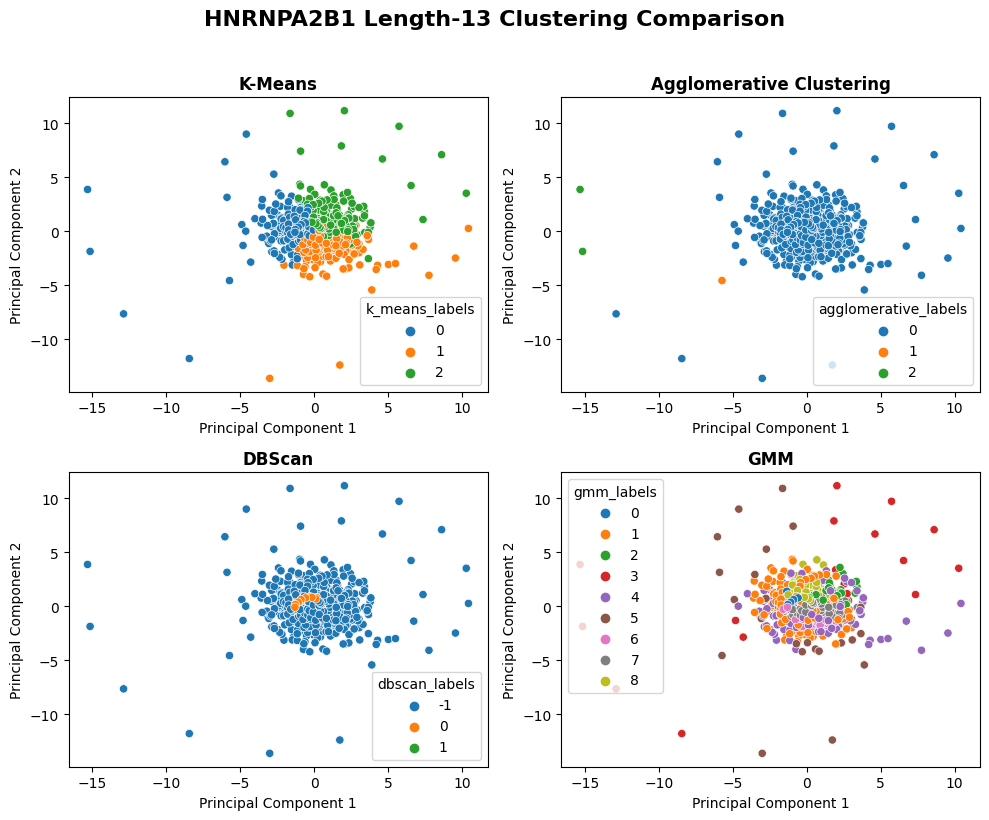

In [25]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan",
    "gmm_labels": "GMM"
}
feature_cols=[f"val{i}" for i in range(1, 14)]

plot_cluster_grid(binding_sites_df_1[13].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPA2B1 Length-13 Clustering Comparison")

#### Full Results

Extracts the consensus fSHAPE profiles from the three largest clusters (minimum size of 3). It then searches the target transcripts to identify and rank motifs matching these consensus profiles based on their aS score

In [26]:
fshape_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPA2B1/hnrnpa2b1_search_fshape")
val_cols = [f"val{i}" for i in range(1, 12)]
base_expected_seq = "".join([char for val, char in motiff_1])
final_findings = []

for window_size in tqdm(motiff_1_lengths):
    top_clusters = get_top_3_clusters(binding_sites_df_1[window_size],
                                      label_col="k_means_labels")
    val_cols = [f"val{i}" for i in range(1, window_size + 1)]
    expected_seq = build_expected_seq(base_expected_seq, window_size)
    final_findings = []

    for cluster_df in top_clusters:
        consensus = get_cluster_consensus(cluster_df, val_cols)
        if consensus is None:
            continue
        for file_path in fshape_dir.glob("*.txt"):
            match_df = search_transcript_for_consensus(
                consensus, file_path, expected_seq
            )
            final_findings.append(match_df)

100%|██████████| 3/3 [01:13<00:00, 24.40s/it]


In [27]:
report_df = pd.concat(final_findings).sort_values('aS')
report_df.head(15)

,motif_sequence,position_range,source_file,znEd,ssf,aS,consensus_used,consensus_len
13,GGCGGGGCTAAAG,678-691,hnrnpa2b1_NM_001127230_AURKAIP1.txt,0.8804,10,-1.1958,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
6,TCATGGCCAAGGT,661-674,hnrnpa2b1_NM_006601_PTGES3.txt,0.8312,8,0.3119,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
20,CGGGTGGCCAGTT,1169-1182,hnrnpa2b1_NM_005918_MDH2.txt,0.8444,8,0.4436,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
15,ACTAGGCAGCTAG,1470-1483,hnrnpa2b1_NM_004068_AP2M1.txt,0.6529,6,0.5291,"[1.129, 1.129, 1.073, 0.829, 0.454, 0.0, 0.068...",13
12,CCCTGGGGCAAAA,726-739,hnrnpa2b1_NM_001984_ESD.txt,0.8687,8,0.6870,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
33,CCTGAGGCTGAAG,847-860,hnrnpa2b1_NM_001195129_PRSS56.txt,0.8888,8,0.8877,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
14,CCCAGCCCTGAGA,589-602,hnrnpa2b1_NM_014222_NDUFA8.txt,0.8942,8,0.9416,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
1,GGAAGAGATGGAT,363-376,hnrnpa2b1_NM_004939_DDX1.txt,1.1075,10,1.0746,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
14,TTTGGTGTTGATG,789-802,hnrnpa2b1_NM_001079524_PAICS.txt,0.8232,7,1.2321,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
19,CAGCGGGCTAGGG,1220-1233,hnrnpa2b1_NM_001017964_YDJC.txt,1.1254,10,1.2536,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13


## Conclusions

### Clustering

Based on the clustering metrics and PCA projection it is clear that clustering this dataset is extremely challenging. The data represents a single, massive, dense central core surrounded by a diffuse halo of outliers, rather than distinctly separated groupings.

Agglomerative clustering achieves the best silhouette score alghough in fact, the visual plot shows that most data is grouped into a single cluster with separate labels for extreme outliers failing to discover meaningfull patterns.

Kmeans separates the data into artificial partitions including the outliers which allows to create groups from the dense center despite poor statistical results.

DBSCAN fails to label most of the data and caused a lot of difficulty during parameter selection. Likely, the most dense region in the dataset was found but a lot of data was discarded.

GMM oversegmented the dataset into overlapping distributions while trying to fit too many shapes into a single large and noisy one.

### Final Results

The best match identified our search is the sequence GGCGGGGCTAAAG located at positions 678-691 in the AURKAIP1 transcript with aS score of -1.1958. The vast majority of top hits (13 out of 15) were discovered using the consensus motif starting with [-0.358, 0.041, -0.083...]. This confirms that K-Means successfully isolated a dominant, frequently occurring structural pattern in training data. All of the highest scores were achieved with the 13 length motif search.

## HNRNPC

### Data Loading

In [28]:
protein_path_2 = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPC/hnrnpc_expected_pattern.txt")
motiff_2 = read_protein_pattern(protein_path_2)
motiff_2_lengths = extract_motiff_length(motiff_2)
motiff_2_lengths

[6, 7, 8]

In [29]:
binging_sites_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPC/hnrnpc_binding_sites_fshape")
binding_sites_txts = find_all_txts(binging_sites_dir)
binding_sites_2 = []

for site in binding_sites_txts:
    full_path = Path(binging_sites_dir, site)
    out = read_protein_pattern(full_path)
    binding_sites_2.append(out)

promising_binding_sites_2 = {}
for window_size in motiff_2_lengths:
    promising_binding_sites_2[window_size] = []
    for binding_site in binding_sites_2:
        outs = sliding_window_reactivity(binding_site, window_size=window_size)
        if len(outs) == 0:
            continue
        for out in outs:
            promising_binding_sites_2[window_size].append(out)

In [30]:
binding_sites_df_2= transform_to_dataframes(promising_binding_sites_2)

for key in binding_sites_df_2:
    binding_sites_df_2[key] = binding_sites_df_2[key].dropna()

In [31]:
binding_sites_df_2[6].head(5)

,val1,val2,val3,val4,val5,val6,str_representation
0,0.651594,0.249096,0.122077,0.271743,0.591197,1.785609,ACCTAA
1,0.249096,0.122077,0.271743,0.591197,1.785609,0.391794,CCTAAA
2,0.122077,0.271743,0.591197,1.785609,0.391794,0.796216,CTAAAA
3,0.271743,0.591197,1.785609,0.391794,0.796216,0.431130,TAAAAT
4,0.591197,1.785609,0.391794,0.796216,0.431130,-0.216991,AAAATG


## Clustering

In [32]:
val_cols_6 = [f"val{i}" for i in range(1, 7)]
X_6 = get_scaled_features(binding_sites_df_2[6], val_cols_6)

val_cols_7 = [f"val{i}" for i in range(1, 8)]
X_7 = get_scaled_features(binding_sites_df_2[7], val_cols_7)

val_cols_8 = [f"val{i}" for i in range(1, 9)]
X_8 = get_scaled_features(binding_sites_df_2[8], val_cols_8)

#### Length 6

In [33]:
best_run_6 = optimize_kmeans(X_6, max_k=20)
binding_sites_df_2[6]["k_means_labels"] = best_run_6["labels"]

Clusters: 3 | Silhouette Score: 0.2764
Clusters: 4 | Silhouette Score: 0.2753
Clusters: 5 | Silhouette Score: 0.2658
Clusters: 6 | Silhouette Score: 0.2352
Clusters: 7 | Silhouette Score: 0.1993
Clusters: 8 | Silhouette Score: 0.2170
Clusters: 9 | Silhouette Score: 0.1786
Clusters: 10 | Silhouette Score: 0.1769
Clusters: 11 | Silhouette Score: 0.2017
Clusters: 12 | Silhouette Score: 0.1887
Clusters: 13 | Silhouette Score: 0.1745
Clusters: 14 | Silhouette Score: 0.1754
Clusters: 15 | Silhouette Score: 0.1668
Clusters: 16 | Silhouette Score: 0.1835
Clusters: 17 | Silhouette Score: 0.1569
Clusters: 18 | Silhouette Score: 0.1734
Clusters: 19 | Silhouette Score: 0.1875
Clusters: 20 | Silhouette Score: 0.1563


In [34]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_6, best_run_6_df = optimize_agglomerative(X_6, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_2[6]["agglomerative_labels"] = best_run_6["labels"]
best_run_6_df.head(5)

,linkage,k,metric,silhouette_score,labels
25,average,3,manhattan,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24,average,3,euclidean,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,complete,3,euclidean,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [35]:
best_run_6, best_run_6_df = optimize_dbscan(X_6, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_2[6]["dbscan_labels"] = best_run_6["labels"]
best_run_6_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
10,0.7,4,2,0.190,0.348995,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, -1,..."
9,0.7,3,2,0.177,0.342506,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, -1,..."
7,0.6,5,2,0.303,0.314171,"[0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, -1..."
6,0.6,4,3,0.287,0.298309,"[0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, -1..."
13,0.9,4,2,0.098,0.258859,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1,..."


In [37]:
best_run_6, best_run_6_df = optimize_gmm(
    X_6, 
    n_components_range=range(2, 11)
)

binding_sites_df_2[6]["gmm_labels"] = best_run_6["labels"]
best_run_6_df.head(5)

,n_components,covariance_type,bic,aic,silhouette_score,labels
26,8,diag,5774.34,5307.96,0.0338,"[3, 0, 6, 6, 2, 2, 0, 0, 0, 6, 7, 7, 2, 2, 0, ..."
22,7,diag,5794.23,5386.72,0.0406,"[5, 5, 0, 0, 2, 2, 5, 5, 0, 0, 6, 6, 2, 2, 4, ..."
18,6,diag,5823.14,5474.48,0.0545,"[5, 5, 0, 0, 2, 2, 5, 5, 5, 0, 0, 4, 2, 2, 5, ..."
30,9,diag,5851.99,5326.75,0.0078,"[3, 0, 6, 6, 8, 2, 3, 3, 0, 6, 7, 8, 8, 2, 0, ..."
34,10,diag,5880.46,5296.36,-0.0026,"[3, 0, 6, 6, 8, 2, 3, 0, 0, 6, 6, 8, 8, 2, 0, ..."


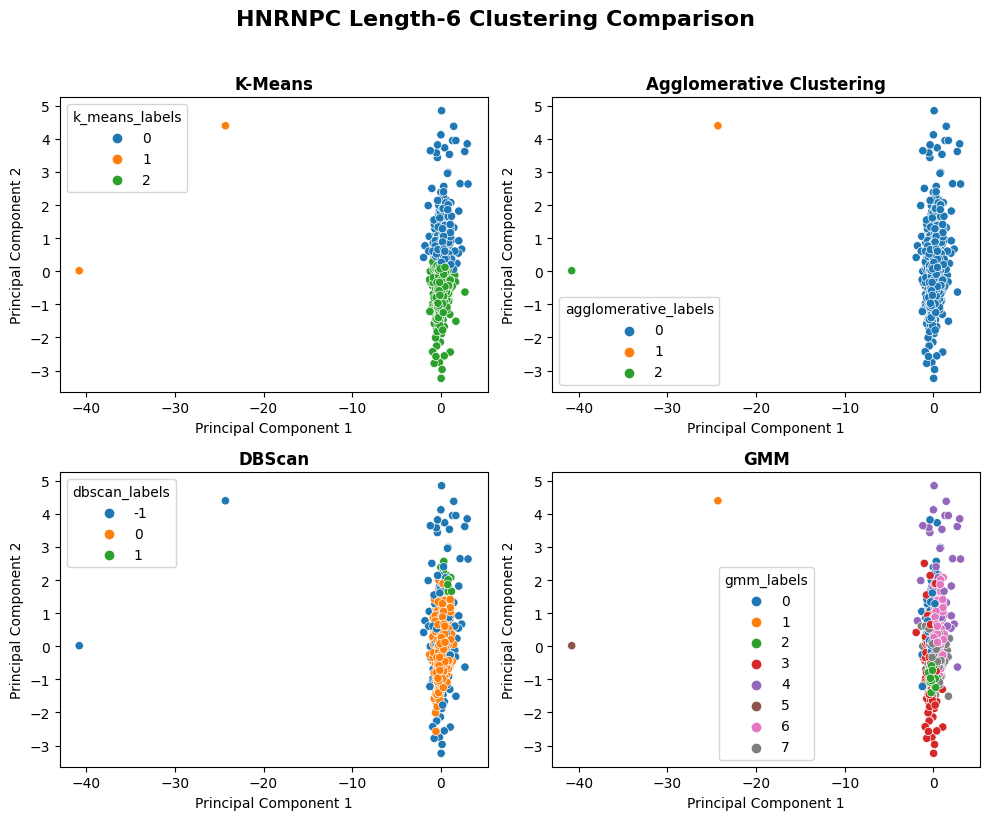

In [38]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan",
    "gmm_labels": "GMM"
}
feature_cols=[f"val{i}" for i in range(1, 7)]

plot_cluster_grid(binding_sites_df_2[6].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPC Length-6 Clustering Comparison")

#### Length 7

In [39]:
best_run_7 = optimize_kmeans(X_7, max_k=20)
binding_sites_df_2[7]["k_means_labels"] = best_run_7["labels"]

Clusters: 3 | Silhouette Score: 0.2889
Clusters: 4 | Silhouette Score: 0.2878
Clusters: 5 | Silhouette Score: 0.2276
Clusters: 6 | Silhouette Score: 0.2352
Clusters: 7 | Silhouette Score: 0.1976
Clusters: 8 | Silhouette Score: 0.1701
Clusters: 9 | Silhouette Score: 0.1816
Clusters: 10 | Silhouette Score: 0.2340
Clusters: 11 | Silhouette Score: 0.1868
Clusters: 12 | Silhouette Score: 0.1875
Clusters: 13 | Silhouette Score: 0.2124
Clusters: 14 | Silhouette Score: 0.1725
Clusters: 15 | Silhouette Score: 0.1685
Clusters: 16 | Silhouette Score: 0.1664
Clusters: 17 | Silhouette Score: 0.1520
Clusters: 18 | Silhouette Score: 0.1434
Clusters: 19 | Silhouette Score: 0.1404
Clusters: 20 | Silhouette Score: 0.1507


In [40]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_7, best_run_7_df = optimize_agglomerative(X_7, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_2[7]["agglomerative_labels"] = best_run_7["labels"]
best_run_7_df.head(5)

,linkage,k,metric,silhouette_score,labels
25,average,3,manhattan,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24,average,3,euclidean,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,complete,3,euclidean,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,complete,3,manhattan,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [41]:
best_run_7, best_run_7_df = optimize_dbscan(X_7, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_2[7]["dbscan_labels"] = best_run_7["labels"]
best_run_7_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
4,0.6,4,2,0.317,0.437971,"[0, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0, 0, 0, 0, 0..."
11,0.8,6,2,0.166,0.413140,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,0.7,4,3,0.212,0.305711,"[0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, ..."
9,0.7,5,3,0.226,0.303895,"[0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, ..."
10,0.8,4,3,0.141,0.225975,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [42]:
best_run_7, best_run_7_df = optimize_gmm(
    X_7, 
    n_components_range=range(2, 11)
)

binding_sites_df_2[7]["gmm_labels"] = best_run_7["labels"]
best_run_7_df.head(5)

,n_components,covariance_type,bic,aic,silhouette_score,labels
22,7,diag,5508.33,5029.95,0.0245,"[0, 0, 0, 5, 5, 6, 0, 0, 0, 5, 5, 5, 6, 6, 6, ..."
18,6,diag,5530.99,5121.60,0.0481,"[0, 0, 0, 5, 5, 2, 0, 0, 0, 5, 5, 5, 2, 2, 2, ..."
26,8,diag,5535.85,4988.46,0.0255,"[0, 0, 0, 6, 6, 4, 0, 0, 0, 6, 6, 6, 4, 4, 4, ..."
34,10,diag,5573.98,4888.60,0.0271,"[0, 0, 0, 6, 6, 4, 0, 0, 0, 6, 6, 9, 9, 4, 4, ..."
30,9,diag,5609.22,4992.84,0.0406,"[0, 0, 0, 6, 6, 4, 0, 0, 0, 6, 6, 6, 4, 4, 4, ..."


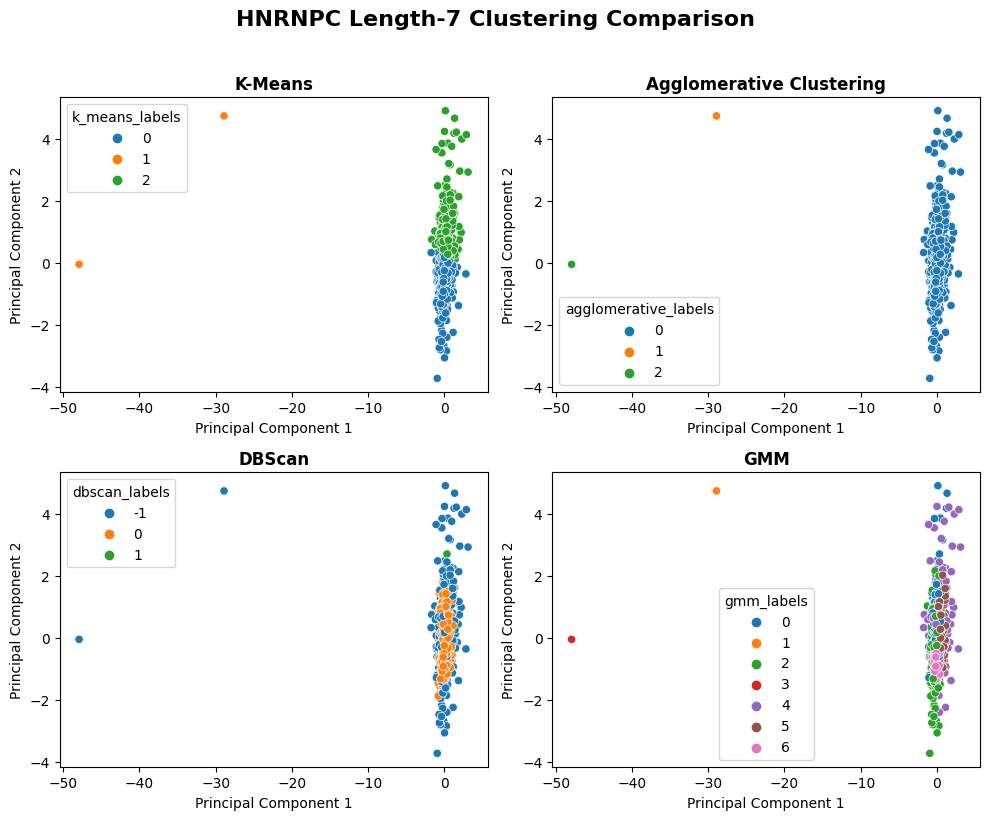

In [43]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan",
    "gmm_labels": "GMM"
}
feature_cols=[f"val{i}" for i in range(1, 8)]

plot_cluster_grid(binding_sites_df_2[7].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPC Length-7 Clustering Comparison")

#### Length 8

In [44]:
best_run_8 = optimize_kmeans(X_8, max_k=20)
binding_sites_df_2[8]["k_means_labels"] = best_run_8["labels"]

Clusters: 3 | Silhouette Score: 0.3034
Clusters: 4 | Silhouette Score: 0.3024
Clusters: 5 | Silhouette Score: 0.2384
Clusters: 6 | Silhouette Score: 0.2196
Clusters: 7 | Silhouette Score: 0.1859
Clusters: 8 | Silhouette Score: 0.2005
Clusters: 9 | Silhouette Score: 0.2074
Clusters: 10 | Silhouette Score: 0.1844
Clusters: 11 | Silhouette Score: 0.2053
Clusters: 12 | Silhouette Score: 0.2157
Clusters: 13 | Silhouette Score: 0.1454
Clusters: 14 | Silhouette Score: 0.1542
Clusters: 15 | Silhouette Score: 0.1764
Clusters: 16 | Silhouette Score: 0.1435
Clusters: 17 | Silhouette Score: 0.1732
Clusters: 18 | Silhouette Score: 0.1417
Clusters: 19 | Silhouette Score: 0.1341
Clusters: 20 | Silhouette Score: 0.1416


In [45]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_8, best_run_8_df = optimize_agglomerative(X_8, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_2[8]["agglomerative_labels"] = best_run_8["labels"]
best_run_8_df.head(5)

,linkage,k,metric,silhouette_score,labels
25,average,3,manhattan,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24,average,3,euclidean,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,complete,3,euclidean,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,complete,3,manhattan,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [46]:
best_run_8, best_run_8_df = optimize_dbscan(X_8, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_2[8]["dbscan_labels"] = best_run_8["labels"]
best_run_8_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
5,0.7,4,3,0.231,0.352755,"[0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, ..."
10,0.8,6,3,0.186,0.344320,"[0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, ..."
4,0.7,3,3,0.222,0.342133,"[0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, ..."
9,0.8,5,3,0.175,0.340748,"[0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, ..."
7,0.8,3,3,0.153,0.329330,"[0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, ..."


In [48]:
best_run_8, best_run_8_df = optimize_gmm(
    X_8, 
    n_components_range=range(2, 11)
)

binding_sites_df_2[8]["gmm_labels"] = best_run_8["labels"]
best_run_8_df.head(5)

,n_components,covariance_type,bic,aic,silhouette_score,labels
34,10,diag,5095.52,4308.54,-0.0616,"[4, 4, 9, 6, 9, 8, 5, 5, 6, 6, 9, 9, 8, 0, 0, ..."
30,9,diag,5103.70,4395.87,-0.0571,"[4, 6, 6, 6, 6, 8, 5, 5, 5, 6, 6, 8, 8, 0, 0, ..."
26,8,diag,5125.65,4496.99,-0.0496,"[7, 6, 6, 6, 6, 4, 5, 5, 5, 6, 6, 4, 4, 0, 0, ..."
22,7,diag,5177.74,4628.24,-0.0351,"[0, 0, 2, 2, 2, 5, 0, 0, 0, 2, 2, 5, 5, 6, 6, ..."
18,6,diag,5239.60,4769.27,0.0104,"[5, 5, 5, 2, 2, 0, 5, 5, 5, 5, 2, 2, 2, 0, 0, ..."


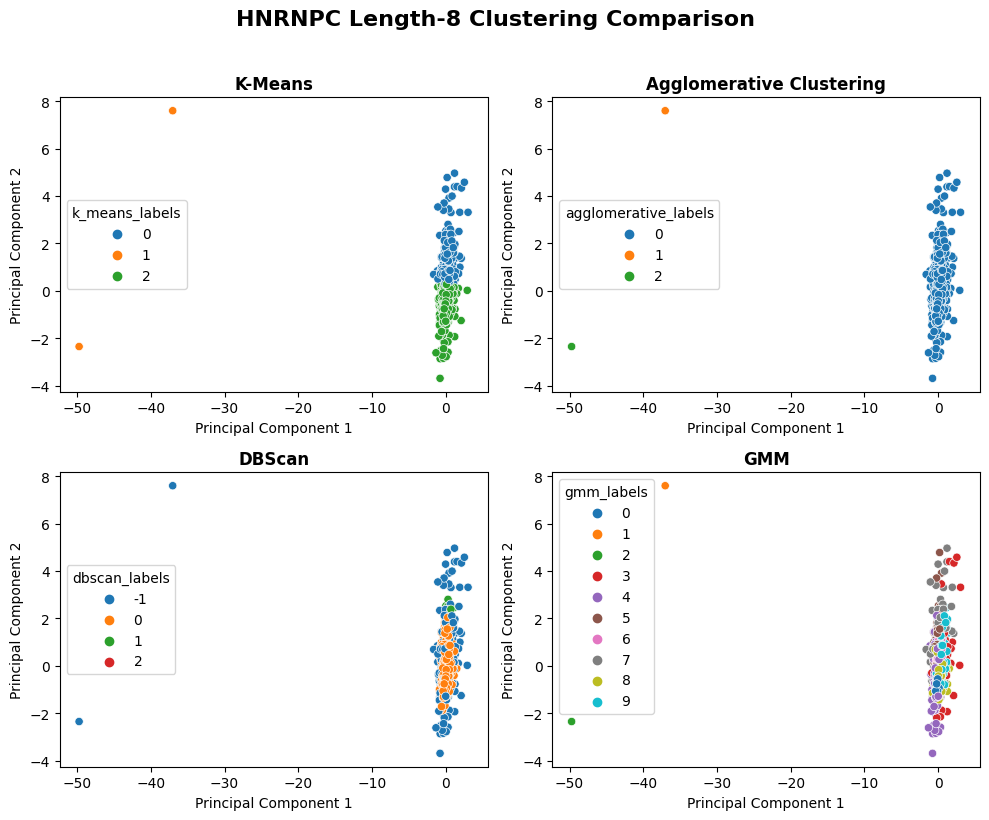

In [49]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan",
    "gmm_labels": "GMM"
}
feature_cols=[f"val{i}" for i in range(1, 9)]

plot_cluster_grid(binding_sites_df_2[8].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPC Length-8 Clustering Comparison")

#### Final Results

In [50]:
fshape_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPC/hnrnpc_search_fshape")
val_cols = [f"val{i}" for i in range(1, 7)]
base_expected_seq = "".join([char for val, char in motiff_2])
final_findings = []

for window_size in tqdm(motiff_2_lengths):
    top_clusters = get_top_3_clusters(binding_sites_df_2[window_size],
                                      label_col="k_means_labels")
    val_cols = [f"val{i}" for i in range(1, window_size + 1)]
    expected_seq = build_expected_seq(base_expected_seq, window_size)
    final_findings = []

    for cluster_df in top_clusters:
        consensus = get_cluster_consensus(cluster_df, val_cols)
        if consensus is None:
            continue
        for file_path in fshape_dir.glob("*.txt"):
            match_df = search_transcript_for_consensus(
                consensus, file_path, expected_seq
            )
            final_findings.append(match_df)

100%|██████████| 3/3 [00:09<00:00,  3.12s/it]


In [51]:
report_df = pd.concat(final_findings).sort_values('aS')
report_df.head(15)

,motif_sequence,position_range,source_file,znEd,ssf,aS,consensus_used,consensus_len
33,GATGTTGT,1129-1137,hnrnpc_NM_006317_BASP1.txt,0.3378,6,-2.6219,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
117,GGCTGTGC,2527-2535,hnrnpc_NM_001136025_PLS3.txt,0.3963,5,-1.0370,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
0,ACCCATTC,55-63,hnrnpc_NM_133639_RHOV.txt,0.3058,4,-0.9417,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
20,CTTTTTCA,1329-1337,hnrnpc_NM_014214_IMPA2.txt,0.7088,8,-0.9125,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
199,CCCCCTGC,3371-3379,hnrnpc_NM_001875_CPS1.txt,0.4163,5,-0.8371,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
0,AATGTGTC,10-18,hnrnpc_NM_001017365_C4BPB.txt,0.3916,4,-0.0841,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
16,GACCTGAC,812-820,hnrnpc_NM_002901_RCN1.txt,0.4029,4,0.0292,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
22,TCCTTTTT,835-843,hnrnpc_NM_007019_UBE2C.txt,0.7244,7,0.2436,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
26,AGTTTCTA,1281-1289,hnrnpc_NM_020130_C8orf4.txt,0.7415,7,0.4152,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
42,AGATATTT,1552-1560,hnrnpc_NM_006317_BASP1.txt,0.4465,4,0.4649,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8


## Conclusions

### Clustering

Clustering this dataset was also a difficult task. Similarily to the previous case, the data forms a single noisy aggregation, this time with two extreme outliers. The results of clustering algorithms were similar with kmeans creating two artificial partitions of the main clump of data with a seperate class for the two outliers and agglomerative clustering creating a single cluster with separate outlier classes. DBSCAN managed to perform slightly better although most data was still ungrouped. GMM again performed best on the overly complex representation which likely does not model the data correctly.

### Final Results

In the final results, multiple candidates with negative aS scores were identified with the best GATGTTGT from the BASP1 file achieving the score of -2.6219. Each of the 15 best results belong to the same consensus motif in length of 8.